In [18]:
import numpy as np
import pandas as pd
from scipy import ndimage
from scipy.signal import resample
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns

In [2]:
def separate_sides(pi_data):
    left_df = pi_data[pi_data['foot'] == 'left']
    right_df = pi_data[pi_data['foot'] == 'right']

    left_data = pi_reshape(left_df)
    right_data = pi_reshape(right_df)
    return left_data, right_data

In [14]:
def pi_reshape(side_df):
    """
    reshapes continuous df to 3D array [31 x 11 x number of frames]
    :param side_df: continuous df
    :return: 3d array [31 x 11 x number of frames]
    """
    frames = side_df['frame'].unique()
    side_array = np.empty([31,11,frames[-1]])
    for i in frames:
        side_array[:, :, i - 1] = side_df.loc[side_df['frame'] == i, '0':'10'].values
    return side_array

In [4]:
def pi_force(array3):
    return np.sum(np.sum(array3, axis=0), axis=0)

In [5]:
# IC & TO detection
def pi_step_segmentation(force_left, force_right, sampling_rate_pi):
    """
    :param force_left:
    :param force_right:
    :param sampling_rate_pi:
    :return:
    """
    IC_left = pi_ic(force_left, sampling_rate_pi)
    IC_right = pi_ic(force_right, sampling_rate_pi)
    TO_left = pi_to(force_left, IC_left)
    TO_right = pi_to(force_right, IC_right)
    events_dict = {'IC_left': np.array(IC_left[:-1]),
              'IC_right': np.array(IC_right[:-1]),
              'TO_left': np.array(TO_left),
              'TO_right': np.array(TO_right)
    }
    return events_dict

def pi_ic(force_side, sampling_rate):
    # calculate rate of force development (1st derivative of force)
    rfd = np.diff(force_side, n=1)*sampling_rate   # unit N/s

    # find where rfd > 1500 N/s based on Seiberl et al. (2018)
    rfd_1500 = np.where(rfd > 1500)[0]

    # first IC is when rfd first exceeds 1500 N/s
    IC_side = [rfd_1500[0]]

    # next IC of the same side has to be at least 250 ms away (fs/4)
    for i in range(1, len(rfd_1500)):
        if rfd_1500[i] - rfd_1500[i - 1] > sampling_rate / 4:
            IC_side.append(rfd_1500[i])
    IC_side=np.array(IC_side, dtype=int)
    return IC_side

def pi_to(force_side, IC_side):
    # filter force data (below 20 N threshold --> 0)
    force_side[force_side < 20] = 0
    TO_side=[]

    # loop to find Toe Off after respective IC
    # force = 0 for the first time after IC
    # clip before last IC (there might not be a toe off after)
    for IC in IC_side[:-1]:
        TO_side.extend(np.argwhere(force_side[IC+1:] == 0)[0] + IC+1)
    return TO_side

In [6]:
# extract steps and save in dict
def pi_separate_steps(pi_left, pi_right, pi_events):
    """
    separates the Stance phases for each step and save in dict
    :param pi_left: pressure data left foot 3d array shape [31 x 11 x frames]
    :param pi_right: pressure data right foot 3d array shape [31 x 11 x frames]
    :param pi_events: dict with IC and TO indices for each side
    :return pi_steps: dict with data for each step (stance phase) - values 3d array[31 x 11 x [IC:TO]]
    """
    # init dict
    pi_steps = {}

    # left side
    for i in range(len(pi_events['IC_left'])):
        pi_steps['left_'+str(i)]=pi_left[:,:,pi_events['IC_left'][i]:pi_events['TO_left'][i]]
    # right side
    for i in range(len(pi_events['IC_right'])):
        pi_steps['right_'+str(i)]=pi_right[:,:,pi_events['IC_right'][i]:pi_events['TO_right'][i]]

    return pi_steps

In [7]:
# get COP coordinates for all steps and save in dict
def pi_get_cop(pi_steps):
    """
    calculates COP coordinates for all steps
    :param pi_steps: dict with all steps (stance), 3d array with shape [31 x 11 x (IC:TO)]
    :return cop_dict: dict with COP coordinates as pd.DataFrame (columns = [x, y]) for each step
    """
    # init dict
    cop_dict = {}

    # loop over all steps
    for key in pi_steps:
        # init array for coordinates
        x = np.empty(pi_steps[key].shape[2])
        y = np.empty(pi_steps[key].shape[2])

        # calculate center of mass for each frame
        for frame in range(pi_steps[key].shape[2]):
            y[frame], x[frame]  = ndimage.measurements.center_of_mass(pi_steps[key][:,:,frame])

        # save COP coordinates (time series) in data frame) & append to dict
        cop_dict[key]=pd.DataFrame([x,y], index = ['x', 'y']).T

    return cop_dict

In [8]:
# calculate F, p, A for all steps and safe in dict
def pi_get_fpa(pi_steps, sensor_size):
    """
    calculates Force, Pressure & Contact Area Time Series for each step
    :param pi_steps: dict with all steps (stance), 3d array with shape [31 x 11 x (IC:TO)]
    :return fpa: dict with Force, Pressure, Area TS as pd.DataFrame (columns = [Force, Area, Pressure]) for each step
    """
    # init dict
    fpa_dict = {}

    # loop over all steps
    for key in pi_steps:
        # init arrays for F, A
        f = np.empty(pi_steps[key].shape[2])
        a = np.empty(pi_steps[key].shape[2])
        p = np.empty(pi_steps[key].shape[2])

        # calculate parameters for each frame
        for frame in range(pi_steps[key].shape[2]):
            # Area: count all non-zero sensors, multiply by sensor size
            a[frame] = np.count_nonzero(pi_steps[key][:,:,frame])*sensor_size
            # Force: sum up all pressure values
            f[frame] = np.sum(pi_steps[key][:,:,frame])
            # pressure = F/A when A=!0
            if a[frame]==0:
                p[frame]=0
            else:
                p[frame]=f[frame]/a[frame]

        # save Parameters  (time series) in data frame) & append to dict
        fpa_dict[key] = pd.DataFrame([f, p, a], index=['Force', 'Pressure', 'Area']).T

    return fpa_dict

In [9]:
def pi_dict_resample(input_dict, output_length):
    """
    Resamples Parameters for each Step at a given length into Multi-index DF
    :param input_dict: dict with Parameters as pd DataFrame for each step
    :param output_length: integer with desired output length
    :return df_resampled: Multi-Index DF, first level: parameters, second level: steps
    """
    # get list with steps
    steps = list(input_dict.keys())
    # get list with parameters
    parameters = list(list(input_dict.values())[0].columns)

    # resample dict via dict comprehension and re-create pd DataFrame as Dict Values
    dict_resampled = {key:pd.DataFrame(resample(value,output_length), columns= value.columns) for (key,value) in input_dict.items()}

    # initialize nested dict
    nested_dict = {}
    # extract each parameter in separate dict & nest
    for i in range(len(parameters)):
        nested_dict[parameters[i]] = {key: value.iloc[:,i] for (key,value) in dict_resampled.items()}

    # create multiindex df
    dict_of_df = {k: pd.DataFrame(v) for k, v in nested_dict.items()}
    df_resampled = pd.concat(dict_of_df, axis = 1)

    return df_resampled

In [10]:
# optional: Foot Segmetation

# Segmentation in 6 Segments (Medial-Lateral, Forefoot, Midfoot, Rearfoot)
def foot_segmentation(array3):
    forefoot = array3[0:11, :, :]
    midfoot = array3[11:21, :, :]
    rearfoot = array3[21:, :, :]

    if rearfoot[:, 0:6].mean() > rearfoot[:, 6:].mean():
        # if left pressure is bigger than right --> left foot --> needs to be flipped
        forefoot = np.fliplr(forefoot)
        midfoot = np.fliplr(midfoot)
        rearfoot = np.fliplr(rearfoot)

    def med_lat_slice(segment):
        med = segment[:, 0:6, :]
        lat = segment[:, 6:, :]
        return med, lat

    ffm, ffl = med_lat_slice(forefoot)
    mfm, mfl = med_lat_slice(midfoot)
    rfm, rfl = med_lat_slice(rearfoot)

    slices = {'FF_Med': ffm,
              'FF_Lat': ffl,
              'MF_Med': mfm,
              'MF_Lat': mfl,
              'RF_Med': rfm,
              'RF_Lat': rfl}

    return slices

In [204]:
def find_hop(events_dict):
    if events_dict['IC_left'][0]<events_dict['IC_right'][0]:
        first = 'IC_left'
        second = 'IC_right'
    else:
        first = 'IC_right'
        second = 'IC_left'
    for i in range(20):
        if events_dict[first][i+1] < events_dict[second][i]:
            print('found hop at ' + str(i) + '. step '+ first[3:] + ' - index:' + str(events_dict[first][i]))
            return first, i
        elif events_dict[second][i] < events_dict[first][i]:
            print('found hop at ' + str(i) + '. step '+ second[3:] + ' - index: ' + str(events_dict[second][i]))
            return second, i

# Example

In [198]:
df = pd.read_csv(r'D:\Salzburg\julian_cutting_wedges\221122_pi_test\pi_hop1.csv')

In [199]:
left, right = separate_sides(df)

In [200]:
force_left = pi_force(left)
force_right = pi_force(right)

In [191]:
sns.set_theme()

In [207]:
d = pi_step_segmentation(force_left, force_right, 100)
key, idx = find_hop(d)

found hop at 5. step right - index:392


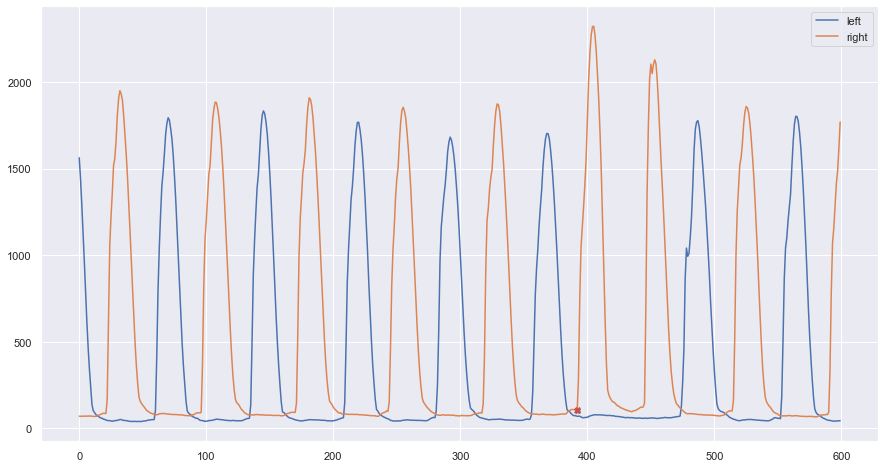

In [211]:
plt.plot(force_left[:600], label='left')
plt.plot(force_right[:600], label='right')
plt.plot(d[key][idx], force_right[d[key][idx]], 'X', c='r', marker)
plt.legend()
fig = plt.gcf()
fig.set_size_inches(15, 8)

found hop at 5. step right - index:392


('IC_right', 5)

In [197]:
[]

IndexError: index 0 is out of bounds for axis 0 with size 0

In [36]:
# get Contact Events
events_dict = pi_step_segmentation(force_left, force_right, 100) # sampling rate = 100 Hz?
events_dict

{'IC_left': array([  59,  134,  208,  280,  355,  473,  552,  627,  701,  775,  851,
         925,  999, 1074, 1148, 1222, 1298, 1372, 1447, 1523, 1598, 1672,
        1748, 1822, 1897, 1973]),
 'IC_right': array([  21,   96,  170,  243,  317,  392,  444,  514,  590,  664,  738,
         813,  887,  962, 1036, 1110, 1184, 1259, 1334, 1409, 1485, 1561,
        1635, 1709, 1783, 1858, 1935, 2010]),
 'TO_left': array([2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090,
        2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090,
        2090, 2090, 2090, 2090], dtype=int64),
 'TO_right': array([2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090,
        2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090,
        2090, 2090, 2090, 2090, 2090, 2090], dtype=int64)}

In [54]:
events_dict['IC_left'][(events_dict['IC_left']<500) & (events_dict['IC_left'] > 20)]

array([ 59, 134, 208, 280, 355, 473])

In [77]:
w1 = 0

In [66]:
events_dict['TO_left']

array([2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090,
       2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090, 2090,
       2090, 2090, 2090, 2090], dtype=int64)

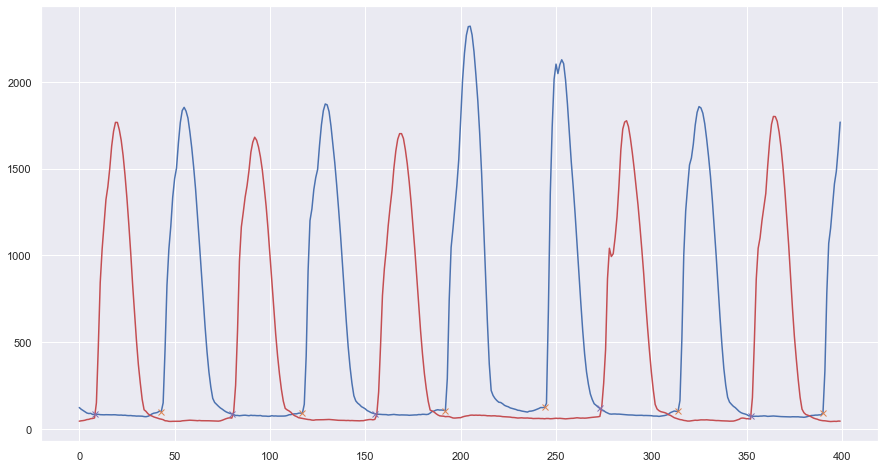

In [79]:
w2 = w1 + 400
forcer = force_right[w1:w2]
icr = events_dict['IC_right'][(events_dict['IC_right'] > w1) & (events_dict['IC_right'] < w2)]-w1
tor = events_dict['TO_right'][(events_dict['TO_right'] > w1) & (events_dict['TO_right'] < w2)]-w1
plt.plot(forcer)
plt.plot(icr, forcer[icr], 'x')
plt.plot(tor, force[tor], 'o')
fig = plt.gcf()
fig.set_size_inches(15, 8)
forcel = force_left[w1:w2]
icl = events_dict['IC_left'][(events_dict['IC_left'] > w1) & (events_dict['IC_left'] < w2)]-w1
tol = events_dict['TO_left'][(events_dict['TO_left'] > w1) & (events_dict['TO_left'] < w2)]-w1
plt.plot(forcel)
plt.plot(icl, forcer[icl], 'x')
plt.plot(tol, force[tol], 'o')

w1 += 200

In [84]:
# find the hop 
print('left:', events_dict['IC_left'])
print('right:', events_dict['IC_right'])

left: [  59  134  208  280  355  473  552  627  701  775  851  925  999 1074
 1148 1222 1298 1372 1447 1523 1598 1672 1748 1822 1897 1973]
right: [  21   96  170  243  317  392  444  514  590  664  738  813  887  962
 1036 1110 1184 1259 1334 1409 1485 1561 1635 1709 1783 1858 1935 2010]


In [ ]:
for i in range(len(events_dict['IC_left'])):
    if events_dict['IC_left'][i] & events_dict['IC_left'][i+1]<

In [145]:
def find_hop(events_dict):
    if events_dict['IC_left'][0]<events_dict['IC_right'][0]:
        first = 'IC_left'
        second = 'IC_right'
    else:
        first = 'IC_right'
        second = 'IC_left'
    for i in range(20):
        if events_dict[first][i+1] < events_dict[second][i]:
            print('found hop at ' + str(i) + '. step '+ first[3:] + ' - index:' + str(events_dict[first][i]))
            return events_dict[first][i]
        elif events_dict[second][i] < events_dict[first][i]:
            print('found hop at ' + str(i) + '. step '+ second[3:] + ' - index: ' + str(events_dict[second][i]))
            return second, i


In [146]:
#pi_step_segmentation(force_left, force_right, 100)['IC_left']
find_hop(d)


found hop at 5. step left - index: 444


('IC_left', 5)

In [144]:
d['IC_left'][5]

444

In [138]:
d={'IC_left': events_dict['IC_right'][1:],
  'IC_right': events_dict['IC_left']}

In [69]:
# separate Steps
steps_dict = pi_separate_steps(left, right, events_dict)

In [39]:
# calculate COP
cop_dict = pi_get_cop(steps_dict)

In [40]:
# calculate force, pressure, area dict
sensor_size = .82**2
fpa_dict = pi_get_fpa(steps_dict, sensor_size)
# resample to 100 samples per step & convert to Multiindex DF
whole_fpa_df = pi_dict_resample(fpa_dict, 100)

In [41]:
whole_fpa_df

Force                                                      \
         left_0       left_1       left_2       left_3       left_4   
0    510.486444   548.720501   387.981567   450.891752   370.930133   
1   1052.474982  1076.789390  1228.225878  1220.695082  1351.170288   
2   -186.758546  -123.724089  -199.751188   -76.305619   -36.115664   
3    137.372086    46.881013   114.859996   104.151708   175.245137   
4    900.410294   847.258108   670.095362   205.335501   -23.914319   
..          ...          ...          ...          ...          ...   
95  1059.137429   937.580211   882.303738   311.322882    10.947437   
96   206.435451    95.509585  -116.543990   149.127133   206.170104   
97  -211.126443  -173.603079    16.916829  -183.462251  -168.152317   
98   928.039481  1026.866845   972.312141  1264.909388  1377.890682   
99   700.193636   632.316257   719.670870   500.898512   434.155324   

                                                                     ...  \
         left_5       left_6       left_7       left_8       left_9  ...   
0    337.633375   465.347773   468.488103   443.006573   426.769510  ...   
1   1496.891373  1504.656319  1504.239858  1544.502367  1533.133704  ...   
2     85.907149     8.584657    90.827163   234.933358   459.378499  ...   
3    139.620143   156.818129    98.433931    12.927631   -98.078534  ...   
4   -107.029492  -127.542925   -46.674598    81.368247   186.713626  ...   
..          ...          ...          ...          ...          ...  ...   
95  -138.305333   -54.773025    77.000290   177.844514   156.029078  ...   
96   180.234533    95.375559   -13.499520  -109.638003  -116.364765  ...   
97   -34.976155   121.060831   329.739566   580.536218   824.732305  ...   
98  1509.537119  1577.355370  1590.870726  1555.502499  1496.944899  ...   
99   311.989708   186.029835    94.243702    20.244813   -55.879787  ...   

          Area                                                              \
      right_18    right_19    right_20    right_21    right_22    right_23   
0   108.456136  109.448191  120.279685  120.477058  112.279923  111.414019   
1   143.403159  142.765558  142.387658  140.698323  137.092390  132.998758   
2   153.749254  156.762906  160.066291  159.616493  158.320551  159.777890   
3    86.266409  102.324332  127.040122  142.389358  152.580708  150.784412   
4    57.187262   69.079235   80.943052  100.805110  126.296022  157.318746   
..         ...         ...         ...         ...         ...         ...   
95   34.020812   38.102931   35.890001   35.126394   35.854576   32.161610   
96   35.352802   31.275824   31.241688   28.716638   24.344597   25.383630   
97   32.350460   33.956557   31.712498   32.517667   37.287296   40.729146   
98   27.268105   25.348007   28.473770   30.360934   30.658597   35.667350   
99   55.613610   63.741232   68.460671   78.057207   93.173046  108.672735   

                                                    
      right_24    right_25    right_26    right_27  
0    92.040270   74.625714   68.576252   43.706000  
1   120.117786   99.322390  107.723781   77.881574  
2   156.595530  153.285041  148.035216  117.083722  
3   149.769307  145.857115  147.282807  119.473974  
4   157.330365  156.145431  151.489156  149.280467  
..         ...         ...         ...         ...  
95   30.499956   38.731052   44.022311  106.239200  
96   31.290968   39.103858   41.451351  136.336578  
97   44.815082   43.086626   81.491294  133.990968  
98   42.668354   75.686661  130.969657  164.432688  
99  135.946417  155.128471  153.186648  127.688688  

[100 rows x 162 columns]

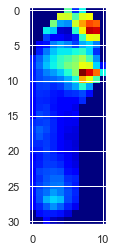

In [43]:
# example step
ex = steps_dict['left_11']
# plot mean of example step
plt.imshow(np.mean(ex, axis=2), cmap='jet', interpolation='nearest')

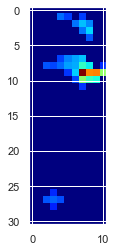

In [44]:
# create animation
fig, ax = plt.subplots()
ims=[]
for i in range(ex.shape[2]):
    im=ax.imshow(ex[:,:,0+i], animated=True, cmap='jet', interpolation='nearest')
    if i==0:
        ax.imshow(ex[:,:,0], cmap='jet', interpolation='nearest')
    ims.append([im])

ani=animation.ArtistAnimation(fig, ims, interval=26.6, blit=True, repeat_delay=10)